In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load preprocessed data
X = np.load("X.npy")
y = np.load("y.npy")

y_cat = to_categorical(y)

# Divide the training/test set
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (10592, 128, 3)
y_train shape: (10592, 4)


In [ ]:
#Construct CNN + LSTM model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(128, 3)))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(LSTM(100))
model.add(Dropout(0.3))

model.add(Dense(100, activation='relu'))
model.add(Dense(4, activation='softmax'))  # Four types of actions

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,144 (301.34 KB)

 Trainable params: 77,144 (301.34 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
#train model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)


Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.7874 - loss: 0.5527 - val_accuracy: 0.9778 - val_loss: 0.0810
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9748 - loss: 0.0942 - val_accuracy: 0.9863 - val_loss: 0.0548
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9872 - loss: 0.0548 - val_accuracy: 0.9906 - val_loss: 0.0389
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9850 - loss: 0.0584 - val_accuracy: 0.9891 - val_loss: 0.0407
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9868 - loss: 0.0523 - val_accuracy: 0.9891 - val_loss: 0.0485
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.9878 - loss: 0.0507 - val_accuracy: 0.9882 - val_loss: 0.0367
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9891 - loss: 0.0385 - val_accuracy: 0.9901 - val_loss: 0.0380
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.9881 - loss: 0.0400 - val_acc

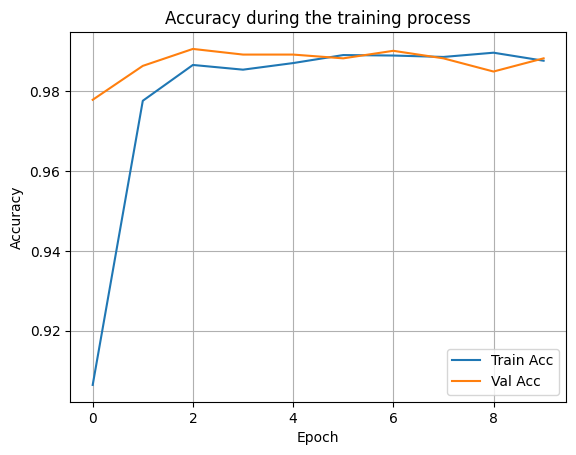

In [ ]:
#Visualize the train process
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy during the training process")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0     0.9990    0.9878    0.9933       980
           1     0.9659    0.9884    0.9770       172
           2     0.9720    0.9720    0.9720       143
           3     0.9912    0.9963    0.9937      1353

    accuracy                         0.9913      2648
   macro avg     0.9820    0.9861    0.9840      2648
weighted avg     0.9914    0.9913    0.9913      2648



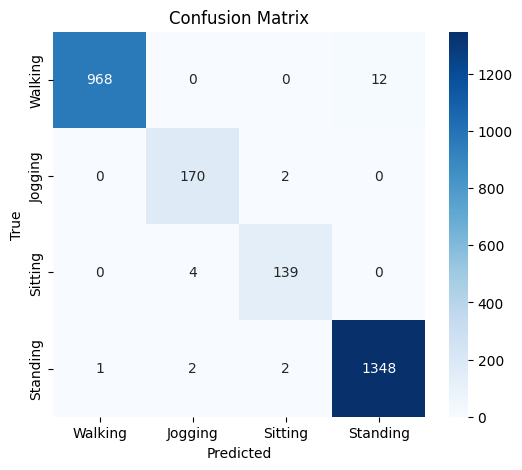

In [6]:
# Prediction
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Report
print(classification_report(y_true, y_pred_classes, digits=4))

# confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Walking', 'Jogging', 'Sitting', 'Standing'], yticklabels=['Walking', 'Jogging', 'Sitting', 'Standing'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
